In [647]:
import pandas as pd
import random
import time
from shapely import Polygon, Point, union_all
from shapely.plotting import plot_polygon
import matplotlib.pyplot as plt

pd.set_option('display.max_rows',20)
random.seed(17)

In [648]:
num_activities = 4
max_tries = 3
prob_blink = 0.1
prob_blink = 0.5

In [649]:
start_time = time.time()

In [650]:
activities = [f'a{i+1}' for i in range(num_activities)]
print(activities)

['a1', 'a2', 'a3', 'a4']


In [651]:
activity_types = {}
for a in activities:
    activity_types[a] = random.sample(['flyby','mower','circle'],1)[0]
print(activity_types)

{'a1': 'circle', 'a2': 'mower', 'a3': 'mower', 'a4': 'mower'}


In [652]:
num_regions = 2**num_activities
coverage = {}
for i in range(num_regions):
    if i>0:
        coverage[f'r{i}'] = [a for j,a in enumerate(activities) if 2**j & i > 0]
regions = [r for r in coverage.keys()]
region_probs = [0.75+random.random() for r in coverage]
region_probs = [p / sum(region_probs) for p in region_probs]
#region_probs = [0,0,0,0,0,0,1] # always vis to all
assert abs(sum(region_probs)-1)<1e-10
print('regions: ',region_probs)
pdf_region = pd.DataFrame({'region': coverage.keys(),
                           'prob': region_probs})
pdf_region['coverage'] = [coverage[r] for r in regions]
pdf_region

regions:  [0.05414156592747125, 0.07895577825656366, 0.0757327999851681, 0.0735019464472059, 0.044795482368756544, 0.04046128031312302, 0.0590653142401742, 0.07792920498055463, 0.052202098942740034, 0.0651809103095121, 0.05558983895944513, 0.083133491321297, 0.08828223612564413, 0.05997250352458498, 0.09105554829775936]


,region,prob,coverage
0,r1,0.054142,[a1]
1,r2,0.078956,[a2]
2,r3,0.075733,"[a1, a2]"
3,r4,0.073502,[a3]
4,r5,0.044795,"[a1, a3]"
5,r6,0.040461,"[a2, a3]"
6,r7,0.059065,"[a1, a2, a3]"
7,r8,0.077929,[a4]
8,r9,0.052202,"[a1, a4]"
9,r10,0.065181,"[a2, a4]"


In [653]:
pos_bench = Point(0,0.27)

In [654]:
footprints = {'a1':Polygon([(-1,0),(1,0),(1,1),(-1,1)]),
              'a2':Polygon([(-1,-1),(1,-1),(1,0),(-1,0)]),
              'a3':Polygon([(-0.25,-1),(0,-1),(0.25,1),(0,1)]),
              'a4':pos_bench.buffer(0.25)
              }
activity_types = {'a1':'mower','a2':'mower','a3':'flyby','a4':'circle'}

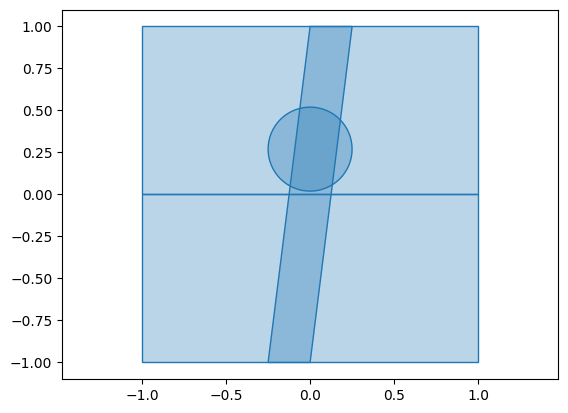

In [655]:
fig,ax = plt.subplots()
for a in activities:
    plot_polygon(footprints[a],ax=ax,add_points=False)
_= ax.axis('equal')

Total search area: 4.0


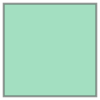

In [656]:
domain = union_all([footprints[a] for a in footprints])
domain_area = domain.area
print('Total search area:',domain_area)
domain

In [657]:
region_polys = dict([(r,domain) for r in regions])
for r in regions:
    for a in activities:
        if a in coverage[r]:
            region_polys[r] = region_polys[r].intersection(footprints[a])
        else:
            region_polys[r] = region_polys[r].difference(footprints[a])
for r in regions:
    if region_polys[r].area==0.0:
        region_polys[r] = Polygon(())
region_polys

{'r1': <MULTIPOLYGON (((1 0, 0.125 0, 0.132 0.058, 0.139 0.062, 0.159 0.077, 0.177 ...>,
 'r2': <MULTIPOLYGON (((-1 0, -0.125 0, -0.25 -1, -1 -1, -1 0)), ((1 -1, 0 -1, 0.12...>,
 'r3': <POLYGON EMPTY>,
 'r4': <POLYGON EMPTY>,
 'r5': <MULTIPOLYGON (((0.18 0.443, 0.177 0.447, 0.159 0.463, 0.139 0.478, 0.118 0....>,
 'r6': <POLYGON ((-0.125 0, 0.125 0, 0 -1, -0.25 -1, -0.125 0))>,
 'r7': <POLYGON EMPTY>,
 'r8': <POLYGON EMPTY>,
 'r9': <MULTIPOLYGON (((0.18 0.443, 0.193 0.429, 0.208 0.409, 0.22 0.388, 0.231 0.3...>,
 'r10': <POLYGON EMPTY>,
 'r11': <POLYGON EMPTY>,
 'r12': <POLYGON EMPTY>,
 'r13': <POLYGON ((0.132 0.058, 0.118 0.05, 0.096 0.039, 0.073 0.031, 0.049 0.025, 0...>,
 'r14': <POLYGON EMPTY>,
 'r15': <POLYGON EMPTY>}

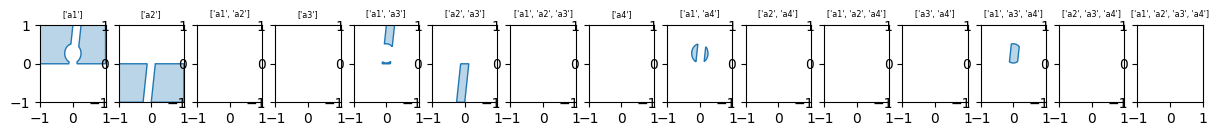

In [658]:
fig,ax = plt.subplots(ncols=num_regions-1,figsize=(15,1))
for i,r in enumerate(regions):
    plot_polygon(region_polys[r],ax=ax[i],add_points=False)
    ax[i].set_title(coverage[r],fontsize='xx-small')
    _= ax[i].axis((-1,1,-1,1))

In [659]:
def close_to(a,b,tol=1e-10):
    return abs(a-b)<tol

In [660]:
cpdf_region_given_anywhere = pd.DataFrame({'region':regions,
                                           '|scenario':'anywhere',
                                           'prob':[region_polys[r].area/domain_area for r in regions]})
assert close_to(sum(cpdf_region_given_anywhere['prob']),1)
cpdf_region_given_anywhere

,region,|scenario,prob
0,r1,anywhere,0.417827
1,r2,anywhere,0.437500
2,r3,anywhere,0.000000
3,r4,anywhere,0.000000
4,r5,anywhere,0.033165
5,r6,anywhere,0.062500
6,r7,anywhere,0.000000
7,r8,anywhere,0.000000
8,r9,anywhere,0.019673
9,r10,anywhere,0.000000


In [661]:
cpdf_region_given_path = pd.DataFrame({'region':regions,
                                           '|scenario':'path',
                                           'prob':[region_polys[r].area/footprints['a3'].area if region_polys[r].intersection(footprints['a3']).area>1e-9 else 0.0 for r in regions]})
assert close_to(sum(cpdf_region_given_path['prob']),1), f'Probability sums to {sum(cpdf_region_given_path['prob'])}'
cpdf_region_given_path

,region,|scenario,prob
0,r1,path,0.000000
1,r2,path,0.000000
2,r3,path,0.000000
3,r4,path,0.000000
4,r5,path,0.265316
5,r6,path,0.500000
6,r7,path,0.000000
7,r8,path,0.000000
8,r9,path,0.000000
9,r10,path,0.000000


In [662]:
cpdf_region_given_bench = pd.DataFrame({'region':regions,
                                           '|scenario':'bench',
                                           'prob':[1.0 if region_polys[r].contains(pos_bench) else 0.0 for r in regions]})
assert close_to(sum(cpdf_region_given_bench['prob']),1), f'Probability sums to {sum(cpdf_region_given_bench['prob'])}'
cpdf_region_given_bench

,region,|scenario,prob
0,r1,bench,0.0
1,r2,bench,0.0
2,r3,bench,0.0
3,r4,bench,0.0
4,r5,bench,0.0
5,r6,bench,0.0
6,r7,bench,0.0
7,r8,bench,0.0
8,r9,bench,0.0
9,r10,bench,0.0


In [663]:
cpdf_region_given_scenario = pd.concat((cpdf_region_given_anywhere,cpdf_region_given_bench,cpdf_region_given_path))
cpdf_region_given_scenario

,region,|scenario,prob
0,r1,anywhere,0.417827
1,r2,anywhere,0.437500
2,r3,anywhere,0.000000
3,r4,anywhere,0.000000
4,r5,anywhere,0.033165
...,...,...,...
10,r11,path,0.000000
11,r12,path,0.000000
12,r13,path,0.234684
13,r14,path,0.000000


In [664]:
scenarios = list(set(cpdf_region_given_scenario['|scenario']))
pdf_scenario = pd.DataFrame({'scenario':scenarios,'prob':[1/len(scenarios) for s in scenarios]})
pdf_scenario = pd.DataFrame({'scenario':scenarios,'prob':[0.4,0.1,0.5]})
pdf_scenario

,scenario,prob
0,path,0.4
1,anywhere,0.1
2,bench,0.5


In [665]:
pdf_region['prob']=sum([pdf_scenario[pdf_scenario['scenario']==s]['prob'].iloc[0]*cpdf_region_given_scenario[cpdf_region_given_scenario['|scenario']==s]['prob'] for s in scenarios])
pdf_region

,region,prob,coverage
0,r1,0.041783,[a1]
1,r2,0.043750,[a2]
2,r3,0.000000,"[a1, a2]"
3,r4,0.000000,[a3]
4,r5,0.109443,"[a1, a3]"
5,r6,0.206250,"[a2, a3]"
6,r7,0.000000,"[a1, a2, a3]"
7,r8,0.000000,[a4]
8,r9,0.001967,"[a1, a4]"
9,r10,0.000000,"[a2, a4]"


In [666]:
pdf_app = pd.DataFrame({'appearance':['blend','neutral','obvious'],
                        'prob' : [0.2,0.4,0.4]})
pdf_app = pd.DataFrame({'appearance':['blend','neutral','obvious'],
                        'prob' : [0.1,0.1,0.8]})
assert sum(pdf_app['prob'])==1
pdf_app

,appearance,prob
0,blend,0.1
1,neutral,0.1
2,obvious,0.8


In [667]:
pdf_occ = pd.DataFrame({'occlusion':['easy','med','hard'],
                        'prob' : [0.5,0.3,0.2]})
pdf_occ = pd.DataFrame({'occlusion':['easy','med','hard'],
                        'prob' : [0.8,0.1,0.1]})
assert sum(pdf_occ['prob'])==1
pdf_occ

,occlusion,prob
0,easy,0.8
1,med,0.1
2,hard,0.1


In [668]:
prob_occ_a_given_occlusion = {'circle':{'hard':0.5,'med':0.3,'easy':0.1},
                              'mower':{'hard':0.7,'med':0.5,'easy':0.3},
                              'flyby':{'hard':0.9,'med':0.7,'easy':0.5},}

In [669]:
#prob_occ_a_given_occlusion = {'circle':{'hard':0.,'med':0.,'easy':0.},
#                              'mower':{'hard':0.,'med':0.,'easy':0.},
#                              'flyby':{'hard':0.,'med':0.,'easy':0.},}

In [670]:
prob_indis_a_given_appearance = {'blend':0.9,'neutral':0.5,'obvious':0.1}

In [671]:
#prob_indis_a_given_appearance = {'blend':0.,'neutral':0.,'obvious':0.}

In [672]:
big_table1 = pd.merge(pdf_app,pdf_occ,how='cross',suffixes=('_app','_occ'))
big_table2 = pd.merge(big_table1,pdf_region,how='cross').rename(columns={'prob':'prob_reg'})
big_table2

,appearance,prob_app,occlusion,prob_occ,region,prob_reg,coverage
0,blend,0.1,easy,0.8,r1,0.041783,[a1]
1,blend,0.1,easy,0.8,r2,0.043750,[a2]
2,blend,0.1,easy,0.8,r3,0.000000,"[a1, a2]"
3,blend,0.1,easy,0.8,r4,0.000000,[a3]
4,blend,0.1,easy,0.8,r5,0.109443,"[a1, a3]"
...,...,...,...,...,...,...,...
130,obvious,0.8,hard,0.1,r11,0.000000,"[a1, a2, a4]"
131,obvious,0.8,hard,0.1,r12,0.000000,"[a3, a4]"
132,obvious,0.8,hard,0.1,r13,0.596807,"[a1, a3, a4]"
133,obvious,0.8,hard,0.1,r14,0.000000,"[a2, a3, a4]"


In [673]:
big_table3 = big_table2
for a in activities:
    big_table3 = pd.merge(big_table3,pd.DataFrame({'num_'+a:range(max_tries+1)}),how='cross')
big_table3

,appearance,prob_app,occlusion,prob_occ,region,prob_reg,coverage,num_a1,num_a2,num_a3,num_a4
0,blend,0.1,easy,0.8,r1,0.041783,[a1],0,0,0,0
1,blend,0.1,easy,0.8,r1,0.041783,[a1],0,0,0,1
2,blend,0.1,easy,0.8,r1,0.041783,[a1],0,0,0,2
3,blend,0.1,easy,0.8,r1,0.041783,[a1],0,0,0,3
4,blend,0.1,easy,0.8,r1,0.041783,[a1],0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
34555,obvious,0.8,hard,0.1,r15,0.000000,"[a1, a2, a3, a4]",3,3,2,3
34556,obvious,0.8,hard,0.1,r15,0.000000,"[a1, a2, a3, a4]",3,3,3,0
34557,obvious,0.8,hard,0.1,r15,0.000000,"[a1, a2, a3, a4]",3,3,3,1
34558,obvious,0.8,hard,0.1,r15,0.000000,"[a1, a2, a3, a4]",3,3,3,2


In [674]:
def prob_det_a(a,r):
    if a not in r['coverage']:
        return 0.0
    if r['num_'+a] <= 0:
        return 0.0
    prob_not_indis_a = r['prob_app']*(1-prob_indis_a_given_appearance[r['appearance']])
    prob_not_occ_a = r['prob_occ']*(1-prob_occ_a_given_occlusion[activity_types[a]][r['occlusion']])
    prob_det = prob_not_indis_a*prob_not_occ_a*r['prob_reg']*(1-prob_blink**r['num_'+a])
    return prob_det

for a in activities:
    big_table3['prob_det_'+a] = big_table3.apply(lambda r: prob_det_a(a,r), axis=1)
big_table3

,appearance,prob_app,occlusion,prob_occ,region,prob_reg,coverage,num_a1,num_a2,num_a3,num_a4,prob_det_a1,prob_det_a2,prob_det_a3,prob_det_a4
0,blend,0.1,easy,0.8,r1,0.041783,[a1],0,0,0,0,0.0,0.0,0.0,0.0
1,blend,0.1,easy,0.8,r1,0.041783,[a1],0,0,0,1,0.0,0.0,0.0,0.0
2,blend,0.1,easy,0.8,r1,0.041783,[a1],0,0,0,2,0.0,0.0,0.0,0.0
3,blend,0.1,easy,0.8,r1,0.041783,[a1],0,0,0,3,0.0,0.0,0.0,0.0
4,blend,0.1,easy,0.8,r1,0.041783,[a1],0,0,1,0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34555,obvious,0.8,hard,0.1,r15,0.000000,"[a1, a2, a3, a4]",3,3,2,3,0.0,0.0,0.0,0.0
34556,obvious,0.8,hard,0.1,r15,0.000000,"[a1, a2, a3, a4]",3,3,3,0,0.0,0.0,0.0,0.0
34557,obvious,0.8,hard,0.1,r15,0.000000,"[a1, a2, a3, a4]",3,3,3,1,0.0,0.0,0.0,0.0
34558,obvious,0.8,hard,0.1,r15,0.000000,"[a1, a2, a3, a4]",3,3,3,2,0.0,0.0,0.0,0.0


In [675]:
big_table3['prob_row'] = big_table3['prob_app']*big_table3['prob_occ']*big_table3['prob_reg']

In [676]:
big_table3['prob_det_in_0'] = 0.0
for n,a in enumerate(activities):
    big_table3[f'prob_det_in_{n+1}'] = big_table3['prob_row']*(big_table3[f'prob_det_in_{n}']/big_table3['prob_row'] + (1-big_table3[f'prob_det_in_{n}']/big_table3['prob_row'])*big_table3['prob_det_'+a]/big_table3['prob_row'])
big_table3 = big_table3.fillna(0.0)
big_table3

,appearance,prob_app,occlusion,prob_occ,region,prob_reg,coverage,num_a1,num_a2,num_a3,...,prob_det_a1,prob_det_a2,prob_det_a3,prob_det_a4,prob_row,prob_det_in_0,prob_det_in_1,prob_det_in_2,prob_det_in_3,prob_det_in_4
0,blend,0.1,easy,0.8,r1,0.041783,[a1],0,0,0,...,0.0,0.0,0.0,0.0,0.003343,0.0,0.0,0.0,0.0,0.0
1,blend,0.1,easy,0.8,r1,0.041783,[a1],0,0,0,...,0.0,0.0,0.0,0.0,0.003343,0.0,0.0,0.0,0.0,0.0
2,blend,0.1,easy,0.8,r1,0.041783,[a1],0,0,0,...,0.0,0.0,0.0,0.0,0.003343,0.0,0.0,0.0,0.0,0.0
3,blend,0.1,easy,0.8,r1,0.041783,[a1],0,0,0,...,0.0,0.0,0.0,0.0,0.003343,0.0,0.0,0.0,0.0,0.0
4,blend,0.1,easy,0.8,r1,0.041783,[a1],0,0,1,...,0.0,0.0,0.0,0.0,0.003343,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34555,obvious,0.8,hard,0.1,r15,0.000000,"[a1, a2, a3, a4]",3,3,2,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
34556,obvious,0.8,hard,0.1,r15,0.000000,"[a1, a2, a3, a4]",3,3,3,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
34557,obvious,0.8,hard,0.1,r15,0.000000,"[a1, a2, a3, a4]",3,3,3,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
34558,obvious,0.8,hard,0.1,r15,0.000000,"[a1, a2, a3, a4]",3,3,3,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


In [677]:
#big_table3.to_excel('bt3.xlsx')

In [678]:
columns_num_a = [col for col in big_table3.columns if col.startswith('num_')]
summary_table = big_table3[columns_num_a].drop_duplicates()
def prob_det_nums(r):
    return sum(big_table3[big_table3[columns_num_a].eq(r).all(axis=1)][f'prob_det_in_{num_activities}'])
summary_table['prob_det'] = summary_table.apply(prob_det_nums,axis=1)
summary_table.sort_values('prob_det',ascending=False)

,num_a1,num_a2,num_a3,num_a4,prob_det
255,3,3,3,3,0.686611
239,3,2,3,3,0.675542
251,3,3,2,3,0.675510
191,2,3,3,3,0.670796
254,3,3,3,2,0.670024
...,...,...,...,...,...
4,0,0,1,0,0.156585
48,0,3,0,0,0.109200
32,0,2,0,0,0.093600
16,0,1,0,0,0.062400


In [679]:
end_time = time.time()
print(f'Ran in {end_time - start_time:.1f} seconds')

Ran in 1.5 seconds


In [680]:
summary_table['num_total'] = sum([summary_table['num_'+a] for a in activities])
summary_table.sort_values('prob_det',ascending=False)

,num_a1,num_a2,num_a3,num_a4,prob_det,num_total
255,3,3,3,3,0.686611,12
239,3,2,3,3,0.675542,11
251,3,3,2,3,0.675510,11
191,2,3,3,3,0.670796,11
254,3,3,3,2,0.670024,11
...,...,...,...,...,...,...
4,0,0,1,0,0.156585,1
48,0,3,0,0,0.109200,3
32,0,2,0,0,0.093600,2
16,0,1,0,0,0.062400,1


In [681]:
summary_table.sort_values('prob_det').drop_duplicates(subset=['num_total'],keep='last')

,num_a1,num_a2,num_a3,num_a4,prob_det,num_total
0,0,0,0,0,0.000000,0
1,0,0,0,1,0.196158,1
65,1,0,0,1,0.327463,2
69,1,0,1,1,0.421503,3
70,1,0,1,2,0.478093,4
86,1,1,1,2,0.530137,5
150,2,1,1,2,0.572884,6
154,2,1,2,2,0.603490,7
170,2,2,2,2,0.626922,8
171,2,2,2,3,0.647045,9


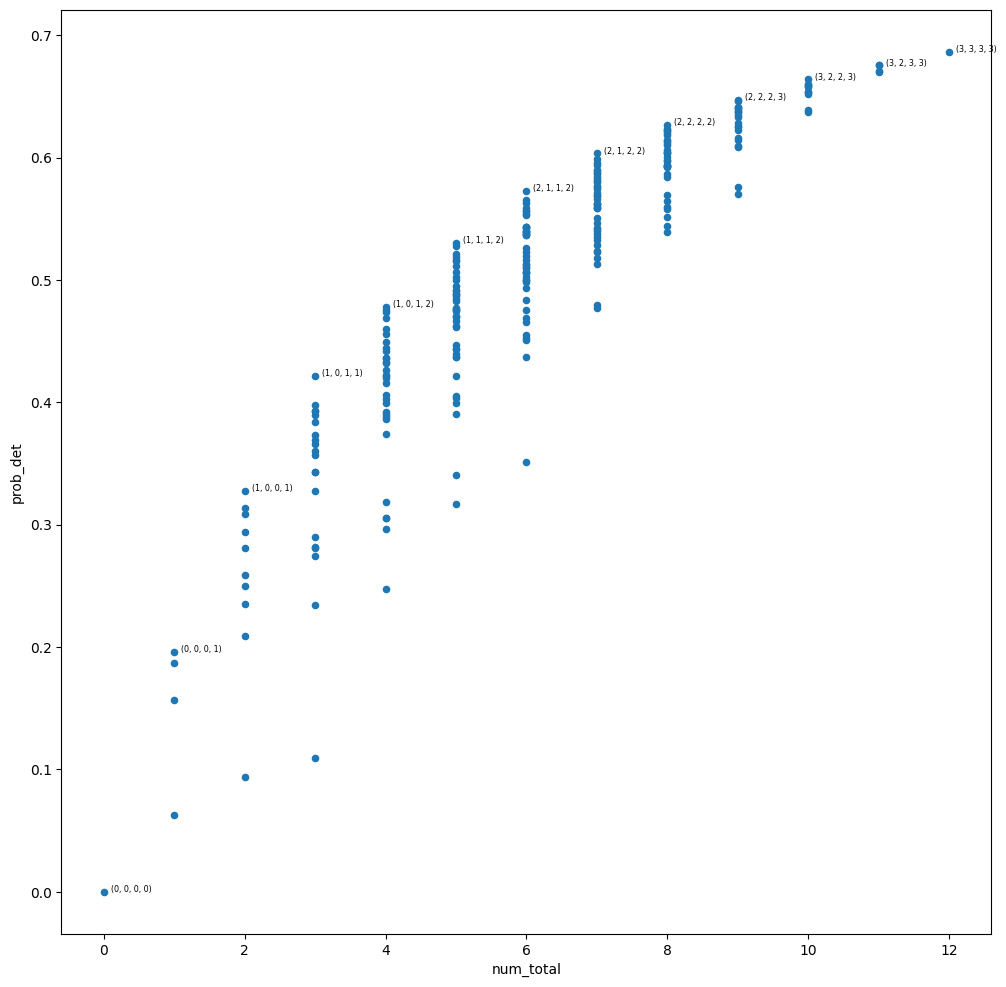

In [682]:
fig,ax=plt.subplots(figsize=(12,12))
summary_table.plot(x='num_total',y='prob_det',kind='scatter',ax=ax)
for i,r in summary_table.sort_values('prob_det').drop_duplicates(subset=['num_total'],keep='last').iterrows():
    ax.annotate(tuple([int(r['num_'+a]) for a in activities]),
                xy = (r['num_total']+0.1,r['prob_det']),
                fontsize='xx-small')